In [1]:
from datasets import load_dataset
local_dir = "./data"

dataset = load_dataset("gfissore/arxiv-abstracts-2021", cache_dir=local_dir)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'abstract', 'report-no', 'categories', 'versions'],
        num_rows: 1999486
    })
})


In [2]:
dataset.set_format(type="pandas")
df = dataset['train'][:]

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999486 entries, 0 to 1999485
Data columns (total 11 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   id           object
 1   submitter    object
 2   authors      object
 3   title        object
 4   comments     object
 5   journal-ref  object
 6   doi          object
 7   abstract     object
 8   report-no    object
 9   categories   object
 10  versions     object
dtypes: object(11)
memory usage: 167.8+ MB


In [4]:
df.head()

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,A fully differential calculation in perturba...,ANL-HEP-PR-07-12,[hep-ph],"[v1, v2]"
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,"We describe a new algorithm, the $(k,\ell)$-...",None,[math.CO cs.CG],"[v1, v2]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,The evolution of Earth-Moon system is descri...,None,[physics.gen-ph],"[v1, v2, v3]"
3,0704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,None,None,We show that a determinant of Stirling cycle...,None,[math.CO],[v1]
4,0704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,None,"Illinois J. Math. 52 (2008) no.2, 681-689",None,In this paper we show how to compute the $\L...,None,[math.CA math.FA],[v1]


In [6]:
df['categories_str'] = df['categories'].apply(
    lambda x: ' '.join(x) if hasattr(x, '__iter__') else str(x)
)


The cmp-lg archive has been subsumed into Computation and Language (cs.CL) since January 1993.(source: https://arxiv.org/archive/cmp-lg)
Thus, **NLP is labeled with the category "cs.CL" and "cmp-lg"**.

In [17]:
df_nlp = df[
    df['categories_str'].str.contains(r'(?<![.\w])cs\.CL(?![.\w])', na=False, regex=True) |
    df['categories_str'].str.contains(r'(?<![.\w])cmp-lg(?![.\w])', na=False, regex=True)
].copy()

print(f"NLP total: {len(df_nlp):,}")

NLP total: 32,221


In [18]:
df_nlp

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions,categories_str,year
2082,0704.2083,Hassan Satori,"H. Satori, M. Harti and N. Chenfour",Introduction to Arabic Speech Recognition Usin...,"4 pages, 3 figures and 2 tables, was in Inform...",None,None,In this paper Arabic was investigated from t...,None,[cs.CL cs.AI],[v1],cs.CL cs.AI,2007
2200,0704.2201,Hassan Satori,"H. Satori, M. Harti and N. Chenfour",Arabic Speech Recognition System using CMU-Sph...,"5 pages, 3 figures and 2 tables, in French",None,None,In this paper we present the creation of an ...,None,[cs.CL cs.AI],[v1],cs.CL cs.AI,2007
3661,0704.3662,Tian-Jian Jiang,"Mike Tian-Jian Jiang, James Zhan, Jaimie Lin, ...",An Automated Evaluation Metric for Chinese Tex...,8 pages,"Jiang, Mike Tian-Jian, et al. ""Robustness anal...",None,"In this paper, we propose an automated evalu...",None,[cs.HC cs.CL],[v1],cs.HC cs.CL,2007
3664,0704.3665,Tian-Jian Jiang,"Mike Tian-Jian Jiang, Deng Liu, Meng-Juei Hsie...",On the Development of Text Input Method - Less...,10 pages,None,None,Intelligent Input Methods (IM) are essential...,None,[cs.CL cs.HC],[v1],cs.CL cs.HC,2007
3707,0704.3708,Bernat Corominas-Murtra BCM,Bernat Corominas-Murtra,Network statistics on early English Syntax: St...,"New abstract. Due to a mistake, abstract from ...",None,None,This paper includes a reflection on the role...,None,[cs.CL],"[v1, v2]",cs.CL,2007
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1752695,cs/9912009,Schwitter,Michael Hess,Deduction over Mixed-Level Logic Representatio...,"8 pages, Proceedings of the Eighth Internation...","IEEE Computer Society Press, 1996. 383-390",10.1109/TAI.1996.560480,A system is described that uses a mixed-leve...,None,[cs.CL],[v1],cs.CL,1999
1752702,cs/9912016,Jin-Dong Kim,Jin-Dong Kim and Sang-Zoo Lee and Hae-Chang Rim,HMM Specialization with Selective Lexicalization,"7 pages, 6 figures",Proceedings of the 1999 Joint SIGDAT Conferenc...,None,We present a technique which complements Hid...,None,[cs.CL cs.LG],[v1],cs.CL cs.LG,1999
1752703,cs/9912017,Schwitter,Michael Hess,Mixed-Level Knowledge Representation and Varia...,29 pages,International Journal on Artificial Intelligen...,None,A system is described that uses a mixed-leve...,None,[cs.CL],[v1],cs.CL,1999
1962853,physics/0307117,Yampol'skii,"O. V. Usatenko, V. A. Yampol'skii, K. E. Keche...",Symbolic stochastic dynamical systems viewed a...,"14 pages, 13 figures",None,10.1103/PhysRevE.68.061107,A theory of systems with long-range correlat...,None,[physics.data-an cond-mat.stat-mech cs.CL math...,[v1],physics.data-an cond-mat.stat-mech cs.CL math-...,2003


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [20]:
def get_year_from_id(arxiv_id):
    try:
        arxiv_id_str = str(arxiv_id)
        
        # For Old format, like 'hep-ph/9711200' -> '97' -> 1997
        if '/' in arxiv_id_str:
            yy_str = arxiv_id_str.split('/')[1][:2]
        else:
        # For New format, numeric (considering leading zero loss)
            # take the part before the dot, if not enough 4 digits, pad with zeros
            # e.g. '704.0001' -> '704' -> '0704' ->  '07' -> 2007
            prefix = arxiv_id_str.split('.')[0]
            yy_str = prefix.zfill(4)[:2]
            
        yy_int = int(yy_str)
        
        # Boundary: 00-21 --- 2000-2021, others --- 19XX
        if 0 <= yy_int <= 21:
            return 2000 + yy_int
        else:
            return 1900 + yy_int
    except:
        return np.nan



In [21]:
df_nlp['year'] = df_nlp['id'].apply(get_year_from_id)

#  outliers removal  + convert to integers
df_nlp = df_nlp.dropna(subset=['year'])
df_nlp['year'] = df_nlp['year'].astype(int)

print(f"count_num: {len(df_nlp)}")
print(f"range: {df_nlp['year'].min()} - {df_nlp['year'].max()}")

count_num: 32221
range: 1994 - 2021


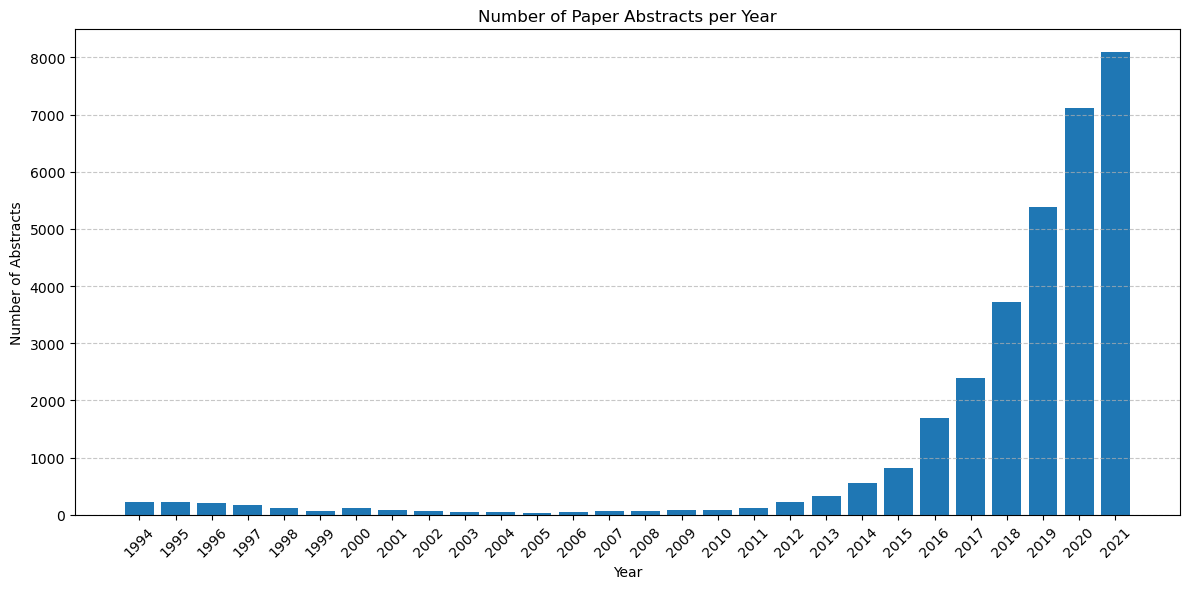

In [23]:
year_counts = df_nlp['year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel('Year')
plt.ylabel('Number of Abstracts')
plt.title('Number of Paper Abstracts per Year')
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [24]:
df_nlp.isnull().sum()

id                    0
submitter            80
authors               0
title                 0
comments           9519
journal-ref       28421
doi               29195
abstract              0
report-no         31823
categories            0
versions              0
categories_str        0
year                  0
dtype: int64

In [26]:
df_nlp[df_nlp['year']<1994].sort_values('year')

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions,categories_str,year


In [27]:
PERIOD_BINS   = [1990, 1995, 2000, 2005, 2010, 2015, 2021]   
PERIOD_LABELS = ["1991-1995", "1996-2000", "2001-2005",
                 "2006-2010", "2011-2015", "2016-2021"]       

In [28]:
df_nlp["period"] = pd.cut(
    df_nlp["year"],
    bins=PERIOD_BINS,
    labels=PERIOD_LABELS,
    right=True
)

df_nlp["period"] = df_nlp["period"].astype(str) # for later groupby

Since the dataset is only up to the end of 2021, the data volume of a single year would be much less than that of the other five years. Incorporating it into the TF-Idf_nlp matrix would lower the word frequency of this period, affecting the comparability of cosine distance and PCA.

Therefore, **the last segment includes 2021**

In [29]:
ERA_MAP = {
    "1991-1995": "Statistical Methods",
    "1996-2000": "Statistical Methods",
    "2001-2005": "Machine Learning",
    "2006-2010": "Machine Learning",
    "2011-2015": "Deep Learning",
    "2016-2021": "Transformer & Pre-training",
}

# add technical labels
df_nlp["era"] = df_nlp["period"].map(ERA_MAP)

In [30]:
df_nlp

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions,categories_str,year,period,era
2082,0704.2083,Hassan Satori,"H. Satori, M. Harti and N. Chenfour",Introduction to Arabic Speech Recognition Usin...,"4 pages, 3 figures and 2 tables, was in Inform...",None,None,In this paper Arabic was investigated from t...,None,[cs.CL cs.AI],[v1],cs.CL cs.AI,2007,2006-2010,Machine Learning
2200,0704.2201,Hassan Satori,"H. Satori, M. Harti and N. Chenfour",Arabic Speech Recognition System using CMU-Sph...,"5 pages, 3 figures and 2 tables, in French",None,None,In this paper we present the creation of an ...,None,[cs.CL cs.AI],[v1],cs.CL cs.AI,2007,2006-2010,Machine Learning
3661,0704.3662,Tian-Jian Jiang,"Mike Tian-Jian Jiang, James Zhan, Jaimie Lin, ...",An Automated Evaluation Metric for Chinese Tex...,8 pages,"Jiang, Mike Tian-Jian, et al. ""Robustness anal...",None,"In this paper, we propose an automated evalu...",None,[cs.HC cs.CL],[v1],cs.HC cs.CL,2007,2006-2010,Machine Learning
3664,0704.3665,Tian-Jian Jiang,"Mike Tian-Jian Jiang, Deng Liu, Meng-Juei Hsie...",On the Development of Text Input Method - Less...,10 pages,None,None,Intelligent Input Methods (IM) are essential...,None,[cs.CL cs.HC],[v1],cs.CL cs.HC,2007,2006-2010,Machine Learning
3707,0704.3708,Bernat Corominas-Murtra BCM,Bernat Corominas-Murtra,Network statistics on early English Syntax: St...,"New abstract. Due to a mistake, abstract from ...",None,None,This paper includes a reflection on the role...,None,[cs.CL],"[v1, v2]",cs.CL,2007,2006-2010,Machine Learning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1752695,cs/9912009,Schwitter,Michael Hess,Deduction over Mixed-Level Logic Representatio...,"8 pages, Proceedings of the Eighth Internation...","IEEE Computer Society Press, 1996. 383-390",10.1109/TAI.1996.560480,A system is described that uses a mixed-leve...,None,[cs.CL],[v1],cs.CL,1999,1996-2000,Statistical Methods
1752702,cs/9912016,Jin-Dong Kim,Jin-Dong Kim and Sang-Zoo Lee and Hae-Chang Rim,HMM Specialization with Selective Lexicalization,"7 pages, 6 figures",Proceedings of the 1999 Joint SIGDAT Conferenc...,None,We present a technique which complements Hid...,None,[cs.CL cs.LG],[v1],cs.CL cs.LG,1999,1996-2000,Statistical Methods
1752703,cs/9912017,Schwitter,Michael Hess,Mixed-Level Knowledge Representation and Varia...,29 pages,International Journal on Artificial Intelligen...,None,A system is described that uses a mixed-leve...,None,[cs.CL],[v1],cs.CL,1999,1996-2000,Statistical Methods
1962853,physics/0307117,Yampol'skii,"O. V. Usatenko, V. A. Yampol'skii, K. E. Keche...",Symbolic stochastic dynamical systems viewed a...,"14 pages, 13 figures",None,10.1103/PhysRevE.68.061107,A theory of systems with long-range correlat...,None,[physics.data-an cond-mat.stat-mech cs.CL math...,[v1],physics.data-an cond-mat.stat-mech cs.CL math-...,2003,2001-2005,Machine Learning


In [31]:
# group by period
period_counts = (
    df_nlp.groupby("period", sort=True)
    .agg(count=("year", "count"),
         year_min=("year", "min"),
         year_max=("year", "max"),
         era=("era", "first"))
    .reset_index()
)

print(period_counts.to_string(index=False))

   period  count  year_min  year_max                        era
1991-1995    448      1994      1995        Statistical Methods
1996-2000    659      1996      2000        Statistical Methods
2001-2005    279      2001      2005           Machine Learning
2006-2010    364      2006      2010           Machine Learning
2011-2015   2066      2011      2015              Deep Learning
2016-2021  28405      2016      2021 Transformer & Pre-training


In [32]:
era_counts = df_nlp.groupby("era")["year"].count().rename("count")
era_counts

era
Deep Learning                  2066
Machine Learning                643
Statistical Methods            1107
Transformer & Pre-training    28405
Name: count, dtype: int64

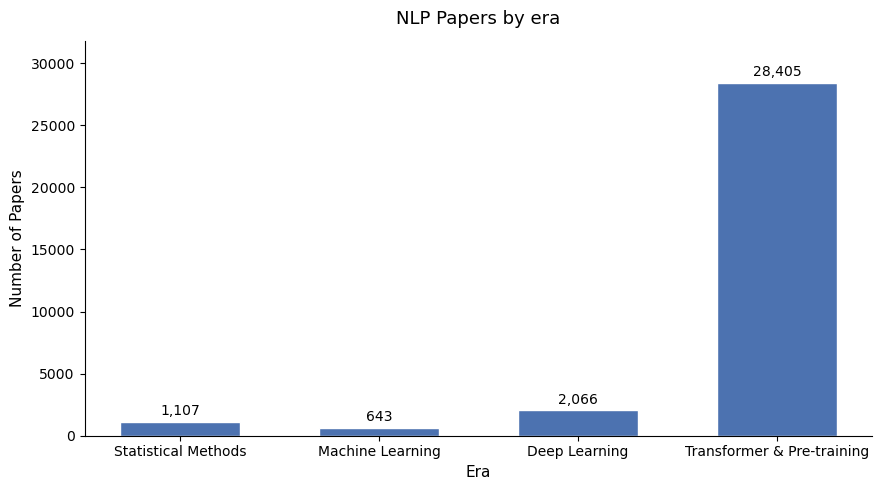

total: 32,221


In [33]:
era_order = ["Statistical Methods", "Machine Learning", "Deep Learning", "Transformer & Pre-training"]
era_counts = era_counts.reindex(era_order)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(era_counts.index, era_counts.values, color="#4C72B0", edgecolor="white", width=0.6)


for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + era_counts.max() * 0.01,
            f"{int(bar.get_height()):,}",
            ha="center", va="bottom", fontsize=10)

ax.set_title("NLP Papers by era", fontsize=13, pad=12)
ax.set_xlabel("Era", fontsize=11)
ax.set_ylabel("Number of Papers", fontsize=11)
ax.set_ylim(0, era_counts.max() * 1.12)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

print(f"total: {len(df_nlp):,}")


In [36]:
df_nlp.to_csv("data/nlp_abstracts_clean.csv", index=False)